# SOCIETY: Backbone × Clusterer Selection with Feature Interpretation

이 노트북은 **DINOv2 vs SigLIP2**, **K-means / DBSCAN / HDBSCAN**, **UMAP vs t-SNE**를 단계적으로 비교하고,
최종적으로 **어떤 조합을 선택할지 근거(품질/안정성/해석성)**를 시각화 중심으로 제시합니다.

**대상 데이터:** `Data/SOCIETY/SOCIETY_final_kr_clean_add_color_text_person_ratio_title.csv`

## 실행 원칙
- 클러스터링은 **원본 임베딩 공간**에서 수행
- UMAP / t-SNE는 **시각화용**
- 최종 선택은 단일 지표가 아니라 **품질 + 안정성 + 피처 해석** 종합


## 이 노트북의 프로세스(처리 흐름) 요약

아래 번호는 본문의 **## 1) … ~ ## 8) …** 절과 대응합니다.

| 단계 | 하는 일 |
|------|--------|
| **1) 설정 및 경로** | 프로젝트 `ROOT`, SOCIETY CSV 경로, 산출물 폴더(`artifacts/.../analysis` 아래 `embeddings`, `plots`, `tables` 등), 임베딩용 GPU/CPU 등 **실험 전역 설정**을 고정합니다. |
| **2) 백본 임베딩** | DINOv2·SigLIP2 등 **비전 백본**으로 썸네일 이미지를 벡터화합니다. 동일 채널의 여러 썸네일은 평균 후 L2 정규화하여 **채널 단위 임베딩**을 만들고, `channel_embeddings.npy`가 있으면 **재추출 없이 로드**합니다. |
| **3) 공통 채널 조인 + 피처 행렬** | CSV에 있는 색·텍스트·인물 비율·연령대 비율 등 **수치 피처를 채널별로 평균** 집계하고, 임베딩 메타데이터의 `channel_id`와 **행 순서를 맞춘 조인**으로 군집·해석에 쓰는 `F`(피처 행렬), `merged`(표)를 준비합니다. |
| **4) 클러스터링 sweep** | **원본 고차 임베딩 공간**에서 K-means, DBSCAN, (설치 시)HDBSCAN 등을 **여러 하이퍼파라미터**로 돌려 라벨을 저장합니다. 실루엣·노이즈 비율 등으로 **후보 run을 점수화**하고 Plot 1–2로 한눈에 비교합니다. |
| **5) 안정성 분석** | 동일 설정에 대해 **시드 변경** 또는 **일부 샘플만 사용**했을 때 라벨이 얼마나 달라지는지(ARI/NMI 등)를 봅니다. Plot 5–6은 “이 군집이 **우연·데이터 조각**에 얼마나 민감한가”를 가늠합니다. |
| **6) UMAP vs t-SNE 시각화** | 군집 자체는 고차에서 수행한 뒤, **2D는 오직 시각화**입니다. UMAP/t-SNE 좌표에 라벨을 얹어(Plot 3–4) 구조를 눈으로 확인합니다. **같은 라벨이라도 2D 투영만 다르면 모양이 달라질 수 있습니다.** |
| **7) 피처 해석** | 선택된(또는 상위) run의 **클러스터 라벨과 보조 피처** 사이 Spearman 등을 보고, UMAP 위에 피처 값을 색으로 겹칩니다(Plot 7a–7b). **Plot 7c**는 스코어 상위 N개 run마다 라벨이 다르므로 **같은 스타일의 그리드를 run별로 반복**합니다. Plot 8–9는 연령 범주·박스플롯으로 **해석 보조**입니다. |
| **8) Permutation 스타일 + 요약** | (Plot 10) 단일 피처를 무작위로 섞었을 때 군집 라벨을 맞추는 정도가 얼마나 무너지는지 등 **단순 예측력 관점**의 점검과, (Plot 11) 최종 후보를 한 장 요약·JSON으로 남깁니다. |

**원칙:** 군집 = **임베딩 공간**, UMAP/t-SNE = **보기용**. DBSCAN `-1`(노이즈)은 “이 설정에서 비할당”이며, **설정이 바뀌면 라벨 의미도 바뀝니다.**


## 1) 설정 및 경로

In [1]:
import os
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')
import sys
print('Python:', sys.executable)
import transformers
print('transformers:', transformers.__version__)
# lazy import는 실패 시 메시지가 모호함 — 여기서 미리 터뜨려 원인 확인
try:
    _ = transformers.AutoImageProcessor
    print('AutoImageProcessor: OK')
except Exception as e:
    chain: list[str] = []
    cur: BaseException | None = e
    while cur is not None:
        chain.append(f'{type(cur).__name__}: {cur}')
        cur = cur.__cause__
    raise RuntimeError(
        'transformers 비전(AutoImageProcessor) 로드 실패.\n'
        '흔한 원인: (1) Jupyter 커널이 conda ytvenv가 아님  (2) torchvision 미설치/깨짐  (3) Pillow 문제\n'
        '조치: 커널을 `...\\anaconda3\\envs\\ytvenv\\python.exe`로 선택 후, 노트북에서\n'
        '  %pip install -U torchvision transformers\n'
        '원인 체인:\n' + '\n'.join(chain)
    ) from e


Python: c:\Users\user\anaconda3\envs\ytvenv\python.exe
transformers: 5.4.0
AutoImageProcessor: OK


In [2]:
# Runtime override: use GPU embedding extraction when CUDA is available
DEVICE_EMB = 'cuda'
print('DEVICE_EMB override ->', DEVICE_EMB)

DEVICE_EMB override -> cuda


In [3]:
from __future__ import annotations

import os
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')
os.environ.setdefault('OMP_NUM_THREADS', '14')

import csv
import json
import re
from collections import defaultdict
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from PIL import Image

from sklearn.cluster import DBSCAN, KMeans
from sklearn.manifold import TSNE
from sklearn.metrics import (
    adjusted_rand_score,
    balanced_accuracy_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    normalized_mutual_info_score,
    silhouette_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import kruskal, chi2_contingency

try:
    import hdbscan  # type: ignore
    HAS_HDBSCAN = True
except Exception:
    HAS_HDBSCAN = False
    print('[warn] hdbscan 미설치: `%pip install hdbscan`')

try:
    import umap  # type: ignore
except Exception as e:
    raise RuntimeError('umap-learn 필요: %pip install umap-learn') from e

def _try_set_cjk_font() -> None:
    plt.rcParams['axes.unicode_minus'] = False
    for f in font_manager.fontManager.ttflist:
        name = f.name or ''
        if any(k in name for k in ('Nanum', 'Noto Sans CJK', 'Malgun', 'AppleGothic', 'Source Han')):
            plt.rcParams['font.family'] = name
            return

_try_set_cjk_font()

# ── 프로젝트 루트 자동 탐색 ──────────────────────────────────────────────
# SOCIETY CSV가 있는 경로를 기준으로 ROOT를 찾습니다.
_SOCIETY_CSV_REL = Path('Data') / 'SOCIETY' / 'SOCIETY_final_kr_clean_add_color_text_person_ratio_title.csv'

def _find_root() -> Path:
    cwd = Path.cwd().resolve()
    for base in [cwd, *cwd.parents]:
        if (base / _SOCIETY_CSV_REL).is_file():
            return base
    # Cursor가 파일 경로로 실행하는 경우 대비: 절대경로 fallback
    for nb_path in Path(__file__).resolve().parents if '__file__' in dir() else []:
        if (nb_path / _SOCIETY_CSV_REL).is_file():
            return nb_path
    raise FileNotFoundError(
        f'SOCIETY CSV를 찾지 못했습니다.\n'
        f'  탐색한 경로: {cwd} (및 상위 폴더들)\n'
        f'  찾는 파일: {{ROOT}}/{_SOCIETY_CSV_REL}'
    )

ROOT = _find_root()
CATEGORY = 'SOCIETY'
DATASET_CSV = ROOT / _SOCIETY_CSV_REL

OUT_BASE = ROOT / 'artifacts' / CATEGORY / 'analysis'
OUT_TABLES = OUT_BASE / 'tables'
OUT_PLOTS  = OUT_BASE / 'plots'
OUT_EMB    = OUT_BASE / 'embeddings'
for d in (OUT_TABLES, OUT_PLOTS, OUT_EMB):
    d.mkdir(parents=True, exist_ok=True)

BACKBONES = {
    'dinov2-base': 'facebook/dinov2-base',
}

DEVICE_EMB         = 'cuda'   # 'cuda' | 'cpu' | 'auto'
BATCH_SIZE_EMB     = 32
REBUILD_EMBEDDINGS = False    # True 로 바꾸면 기존 .npy 무시하고 재추출

RANDOM_STATE    = 42
SEEDS_STABILITY = [11, 22, 33, 44, 55]
SUBSAMPLE_FRACS = [0.7, 0.8, 0.9]

K_RANGE                    = list(range(2, 11))
DBSCAN_EPS_LIST            = [0.22, 0.25, 0.28, 0.30, 0.33, 0.36, 0.40]
DBSCAN_MIN_SAMPLES_LIST    = [6, 8, 10, 12, 15]
HDBSCAN_MIN_CLUSTER_SIZE_LIST = [20, 30]
HDBSCAN_MIN_SAMPLES_LIST   = [None, 5]

UMAP_NEIGHBORS  = 20
UMAP_MIN_DIST   = 0.1
TSNE_PERPLEXITY = 30

print('ROOT:    ', ROOT)
print('DATASET: ', DATASET_CSV)
print('OUT_BASE:', OUT_BASE)


ROOT:     C:\Users\user\Desktop\26-1_URP
DATASET:  C:\Users\user\Desktop\26-1_URP\Data\SOCIETY\SOCIETY_final_kr_clean_add_color_text_person_ratio_title.csv
OUT_BASE: C:\Users\user\Desktop\26-1_URP\artifacts\SOCIETY\analysis


## 2) Backbone별 채널 임베딩 생성/로드 (DINOv2, SigLIP2)

In [4]:
def _write_csv_rows(path: Path, fieldnames: Sequence[str], rows: Iterable[Dict]) -> None:
    with path.open('w', encoding='utf-8', newline='') as f:
        w = csv.DictWriter(f, fieldnames=fieldnames)
        w.writeheader()
        for row in rows:
            w.writerow(row)


def _read_csv_rows(path: Path, encoding: str = 'utf-8') -> List[Dict[str, str]]:
    with path.open('r', encoding=encoding, newline='') as f:
        return list(csv.DictReader(f))


AUTO_REPAIR_MISSING_THUMBNAILS = True
THUMBNAIL_REPAIR_TIMEOUT_SEC   = 20
THUMBNAIL_REPAIR_RETRIES       = 2


def _thumbnail_path_candidates(raw_path: str, root: Path) -> list[Path]:
    raw = (raw_path or '').strip().replace('\\', os.sep)
    if not raw:
        return []
    p = Path(raw)
    candidates: list[Path] = []
    if p.is_absolute():
        candidates.append(p)
    else:
        candidates.append(root / p)
        parts = p.parts
        if parts and parts[0].lower() == 'data':
            rel = Path(*parts[1:]) if len(parts) > 1 else Path('.')
            candidates.append(root / 'Data' / rel)
        candidates.append(root / 'Data' / p)
    out: list[Path] = []
    seen: set[str] = set()
    for c in candidates:
        rc = str(c)
        if rc not in seen:
            seen.add(rc)
            out.append(c)
    return out


def resolve_thumbnail_path(row: dict, root: Path) -> Path | None:
    # SOCIETY CSV의 썸네일 경로 컬럼은 'thumbnail_path_x'
    raw = (row.get('thumbnail_path_x') or '').strip()
    for c in _thumbnail_path_candidates(raw, root):
        if c.is_file():
            return c
    return None


def _download_thumbnail_for_row(row: dict, root: Path) -> Path | None:
    import requests
    if not AUTO_REPAIR_MISSING_THUMBNAILS:
        return None
    raw = (row.get('thumbnail_path_x') or '').strip()
    url = (row.get('thumbnail_url_x') or '').strip()
    if not raw or not url:
        return None
    candidates = _thumbnail_path_candidates(raw, root)
    if not candidates:
        return None
    target = candidates[0]
    try:
        target.parent.mkdir(parents=True, exist_ok=True)
        last_err = None
        for _ in range(THUMBNAIL_REPAIR_RETRIES):
            try:
                resp = requests.get(url, timeout=THUMBNAIL_REPAIR_TIMEOUT_SEC)
                resp.raise_for_status()
                target.write_bytes(resp.content)
                if target.is_file() and target.stat().st_size > 0:
                    return target
            except Exception as e:
                last_err = e
        if last_err is not None:
            raise last_err
    except Exception:
        return None
    return None


@dataclass
class LoadedModel:
    model_id: str
    alias: str
    processor: object
    model: object
    device: str


def _resolve_device(requested: str) -> str:
    if requested != 'auto':
        return requested
    try:
        import torch
        if torch.cuda.is_available():
            return 'cuda'
    except Exception:
        pass
    return 'cpu'


def _load_transformers_model(alias: str, model_id: str, device: str) -> LoadedModel:
    from transformers import AutoImageProcessor, AutoModel, AutoProcessor
    model = AutoModel.from_pretrained(model_id)
    try:
        processor = AutoProcessor.from_pretrained(model_id)
    except Exception:
        processor = AutoImageProcessor.from_pretrained(model_id)
    model = model.to(device).eval()
    return LoadedModel(model_id=model_id, alias=alias, processor=processor, model=model, device=device)


def _extract_batch_embeddings(loaded: LoadedModel, images: list) -> list[np.ndarray]:
    import torch
    inputs = loaded.processor(images=images, return_tensors='pt')
    inputs = {k: v.to(loaded.device) for k, v in inputs.items() if isinstance(v, torch.Tensor)}
    with torch.no_grad():
        outputs = loaded.model(**inputs)
    if hasattr(outputs, 'last_hidden_state') and outputs.last_hidden_state is not None:
        emb = outputs.last_hidden_state[:, 0, :]
    elif hasattr(outputs, 'pooler_output') and outputs.pooler_output is not None:
        emb = outputs.pooler_output
    else:
        first = outputs[0] if isinstance(outputs, (tuple, list)) else None
        if first is None:
            raise RuntimeError(f'unexpected model output type: {type(outputs)}')
        emb = first[:, 0, :] if first.ndim == 3 else first
    arr = emb.detach().float().cpu().numpy()
    return [arr[i] for i in range(arr.shape[0])]


def _is_cuda_related_error(exc: Exception) -> bool:
    msg = str(exc).lower()
    return any(k in msg for k in ('cuda', 'cudnn', 'nvidia driver', 'no kernel image'))


def build_or_load_channel_embeddings(alias: str, model_id: str) -> Tuple[np.ndarray, pd.DataFrame]:
    model_dir = OUT_EMB / alias
    model_dir.mkdir(parents=True, exist_ok=True)
    emb_path  = model_dir / 'channel_embeddings.npy'
    meta_path = model_dir / 'channel_metadata.csv'
    need = REBUILD_EMBEDDINGS or (not emb_path.is_file()) or (not meta_path.is_file())

    if need:
        # SOCIETY CSV 컬럼명: channel_id_x, channel_name_x, thumbnail_path_x
        rows = _read_csv_rows(DATASET_CSV, encoding='utf-8-sig')
        rows = [r for r in rows if (r.get('channel_id_x') or '').strip()]

        dev = _resolve_device(DEVICE_EMB)
        try:
            loaded = _load_transformers_model(alias, model_id, dev)
        except Exception as e:
            if dev == 'cuda' and _is_cuda_related_error(e):
                print(f'[warn] {alias}: CUDA init failed -> fallback to CPU ({e})')
                loaded = _load_transformers_model(alias, model_id, 'cpu')
            else:
                raise

        runtime_batch  = BATCH_SIZE_EMB if loaded.device == 'cuda' else min(BATCH_SIZE_EMB, 8)
        progress_every = 1 if loaded.device == 'cpu' else 20
        print(
            f'[extract] {alias} ({loaded.model_id}) on {loaded.device} '
            f'/ rows={len(rows)} / batch={runtime_batch} / progress_every={progress_every}'
        )

        valid_meta: list[Dict[str, str]] = []
        emb_list: list[np.ndarray] = []
        missing_path_count = 0
        missing_path_samples: list[str] = []
        open_fail_count = 0

        for i in range(0, len(rows), runtime_batch):
            chunk = rows[i : i + runtime_batch]
            images, metas = [], []
            repaired = 0
            for r in chunk:
                p = resolve_thumbnail_path(r, ROOT)
                if p is None:
                    p = _download_thumbnail_for_row(r, ROOT)
                    if p is not None:
                        repaired += 1
                if p is None:
                    missing_path_count += 1
                    raw = str((r.get('thumbnail_path_x') or '')).strip()
                    if raw and len(missing_path_samples) < 8:
                        missing_path_samples.append(raw)
                    continue
                try:
                    with Image.open(p) as img:
                        images.append(img.convert('RGB'))
                    metas.append({
                        'channel_id':   str(r.get('channel_id_x',   '')).strip(),
                        'channel_name': str(r.get('channel_name_x', '')).strip(),
                    })
                except Exception:
                    open_fail_count += 1
                    continue
            if repaired:
                print(f'  repaired thumbnails in chunk: +{repaired}')
            if not images:
                continue
            try:
                batch_emb = _extract_batch_embeddings(loaded, images)
            except Exception as e:
                if loaded.device == 'cuda' and _is_cuda_related_error(e):
                    print(f'[warn] CUDA batch failed at row={i} -> CPU')
                    loaded = _load_transformers_model(alias, model_id, 'cpu')
                    batch_emb = _extract_batch_embeddings(loaded, images)
                else:
                    raise
            emb_list.extend(batch_emb)
            valid_meta.extend(metas)
            if (i // runtime_batch) % progress_every == 0:
                print(f'  progress: {i}/{len(rows)} (device={loaded.device})')

        if not emb_list:
            raise RuntimeError(
                f'no embeddings extracted for {alias}.\n'
                f'missing thumbnail_path_x count={missing_path_count}, open_fail={open_fail_count}\n'
                f'sample missing paths={missing_path_samples[:5]}'
            )

        X_vid = np.asarray(emb_list, dtype=np.float32)
        _write_csv_rows(model_dir / 'video_metadata.csv', ['channel_id', 'channel_name'], valid_meta)
        np.save(model_dir / 'video_embeddings.npy', X_vid)

        groups: dict[str, list[int]] = defaultdict(list)
        ch_name: dict[str, str] = {}
        for i, r in enumerate(valid_meta):
            cid = str(r['channel_id']).strip()
            if not cid:
                continue
            groups[cid].append(i)
            ch_name[cid] = str(r.get('channel_name', '')).strip()

        cids = sorted(groups.keys())
        X_ch = np.stack([X_vid[groups[c]].mean(axis=0) for c in cids], axis=0)
        norms = np.linalg.norm(X_ch, axis=1, keepdims=True)
        norms = np.where(norms < 1e-12, 1.0, norms)
        X_ch = (X_ch / norms).astype(np.float32)

        np.save(emb_path, X_ch)
        rows_out = [
            {'channel_id': c, 'channel_name': ch_name.get(c, ''), 'n_videos': str(len(groups[c]))}
            for c in cids
        ]
        _write_csv_rows(meta_path, ['channel_id', 'channel_name', 'n_videos'], rows_out)
        print(f'  saved: {emb_path} shape={X_ch.shape}')

    X = np.load(emb_path).astype(np.float64)
    meta = pd.read_csv(meta_path, encoding='utf-8')
    meta['channel_id'] = meta['channel_id'].astype(str).str.strip()
    assert X.shape[0] == len(meta), (X.shape, len(meta))
    return X, meta


X_by_backbone:    Dict[str, np.ndarray]    = {}
meta_by_backbone: Dict[str, pd.DataFrame] = {}

for alias, model_id in BACKBONES.items():
    try:
        X_, meta_ = build_or_load_channel_embeddings(alias, model_id)
        X_by_backbone[alias]    = X_
        meta_by_backbone[alias] = meta_
    except Exception as e:
        print(f'[warn] backbone skip: {alias} ({e})')

if not X_by_backbone:
    raise RuntimeError('No backbone embeddings are available.')

print('available backbones:', list(X_by_backbone.keys()))


Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

[extract] siglip2-base (google/siglip2-base-patch16-224) on cuda / rows=48696 / batch=32 / progress_every=20
[warn] backbone skip: siglip2-base (You have to specify input_ids)
available backbones: ['dinov2-base']


## 3) 공통 채널 조인 + 피처 행렬 준비

In [5]:
# SOCIETY CSV에는 피처가 이미 내장되어 있으므로 채널별로 평균 집계합니다.
# 집계 대상 피처 컬럼 (수치형 전체)
FEATURE_COLS = [
    'saturation_mean', 'saturation_std', 'laba_mean', 'labb_mean',
    'color_entropy', 'saturated_ratio',
    'red_ratio', 'orange_ratio', 'yellow_ratio', 'green_ratio',
    'cyan_ratio', 'blue_ratio', 'purple_ratio', 'pink_ratio',
    'text_ratio', 'person_ratio',
    'female_pct', 'male_pct',
    'age_~17', 'age_18~24', 'age_25~34', 'age_35~44',
    'age_45~54', 'age_55~64', 'age_65~',
    'clean_title_x_length',
]

# 원본 CSV 로드 후 채널별 평균
_raw = pd.read_csv(DATASET_CSV, encoding='utf-8-sig', low_memory=False)
_raw = _raw.rename(columns={'channel_id_x': 'channel_id', 'channel_name_x': 'channel_name'})
_raw['channel_id'] = _raw['channel_id'].astype(str).str.strip()

# 피처 컬럼 중 실제 존재하는 것만 사용
feature_cols = [c for c in FEATURE_COLS if c in _raw.columns]
missing_feat = [c for c in FEATURE_COLS if c not in _raw.columns]
if missing_feat:
    print(f'[warn] 피처 컬럼 없음 (건너뜀): {missing_feat}')

# 채널별 피처 평균 집계
feat_df = (
    _raw.groupby('channel_id', as_index=False)
    [['channel_name'] + feature_cols]
    .agg({'channel_name': 'first', **{c: 'mean' for c in feature_cols}})
)
feat_df['channel_id'] = feat_df['channel_id'].astype(str).str.strip()
name_col = 'channel_name'
feat_ids = set(feat_df['channel_id'].tolist())
print(f'채널 수 (피처 집계): {len(feat_df)} | 피처 수: {len(feature_cols)}')

common_ids = set(feat_ids)
for alias, meta in meta_by_backbone.items():
    meta_ids = set(meta['channel_id'].astype(str).tolist())
    before = len(common_ids)
    common_ids &= meta_ids
    print(f'  intersect with {alias}: {before} -> {len(common_ids)} (meta={len(meta_ids)})')

common_ids = sorted(common_ids)
print(f'공통 채널 수 (피처 & 모든 백본): {len(common_ids)}')
if len(common_ids) < 10:
    raise RuntimeError(
        f'공통 채널이 너무 적습니다 ({len(common_ids)}개). '
        f'channel_id 정합성을 확인하세요.'
    )

# 진단
for alias, meta in meta_by_backbone.items():
    meta_ids = set(meta['channel_id'].astype(str).tolist())
    print(f'  diag {alias}: feature_only={len(feat_ids - meta_ids)}, backbone_only={len(meta_ids - feat_ids)}')

# backbone_data 준비
backbone_data: Dict[str, Dict[str, Any]] = {}
feat_df_idx = feat_df.set_index('channel_id')

for alias in X_by_backbone:
    X_all = X_by_backbone[alias]
    meta  = meta_by_backbone[alias].copy()
    meta['channel_id'] = meta['channel_id'].astype(str).str.strip()
    id_to_idx = {cid: i for i, cid in enumerate(meta['channel_id'].tolist())}

    ordered_ids = [cid for cid in common_ids if (cid in feat_df_idx.index and cid in id_to_idx)]
    feat_sub = feat_df_idx.loc[ordered_ids, feature_cols + [name_col]].reset_index()

    idx = [id_to_idx[cid] for cid in ordered_ids]
    X = X_all[idx].astype(np.float64)
    F = feat_sub[feature_cols].apply(pd.to_numeric, errors='coerce').to_numpy(dtype=np.float64)

    merged = feat_sub.copy()
    merged['channel_name_meta'] = [meta.loc[id_to_idx[cid], 'channel_name'] for cid in ordered_ids]

    backbone_data[alias] = {
        'X': X,
        'F': F,
        'merged': merged,
        'feature_cols': feature_cols,
    }
    print(f'  prepared {alias}: X={X.shape}, F={F.shape}, merged={merged.shape}')

print('backbones prepared:', list(backbone_data.keys()))
print('feature count:', len(feature_cols))


채널 수 (피처 집계): 5106 | 피처 수: 26
  intersect with dinov2-base: 5106 -> 5106 (meta=5106)
공통 채널 수 (피처 & 모든 백본): 5106
  diag dinov2-base: feature_only=0, backbone_only=0
  prepared dinov2-base: X=(5106, 768), F=(5106, 26), merged=(5106, 29)
backbones prepared: ['dinov2-base']
feature count: 26


## 4) 클러스터링 sweep (K-means / DBSCAN / HDBSCAN)

### Plot 1
- Backbone × Method best-score heatmap

### Plot 2
- 파라미터 민감도(DBSCAN/HDBSCAN)

,run_id,backbone,method,n_clusters,noise_ratio,sil_pref,score
0,dinov2-base|kmeans|k=2,dinov2-base,kmeans,2,0.000000,0.084693,0.479520
34,dinov2-base|dbscan|eps=0.36|ms=6,dinov2-base,dbscan,2,0.142382,0.193103,0.281503


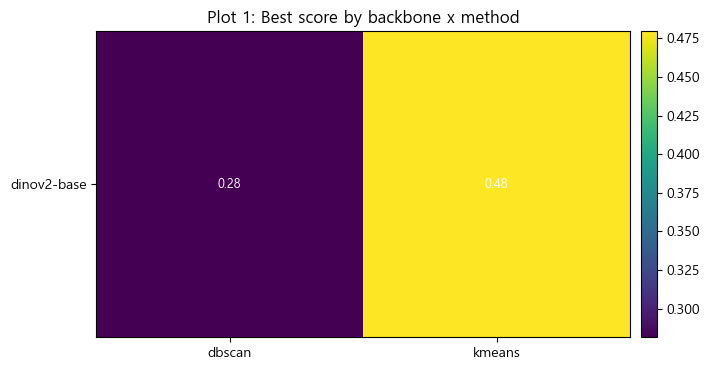

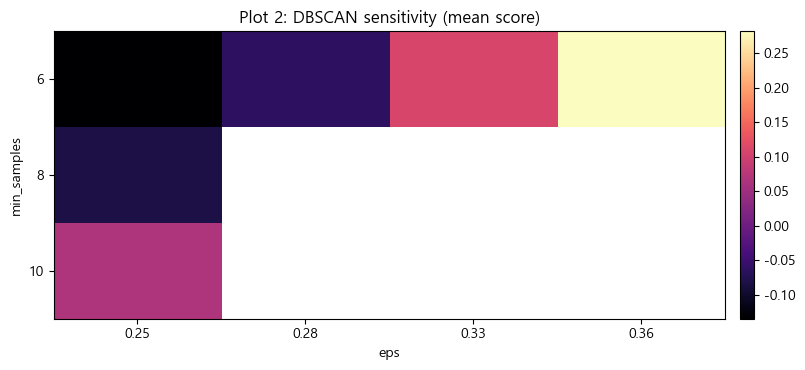

In [6]:
def evaluate_labels(X: np.ndarray, labels: np.ndarray) -> Dict[str, Any]:
    labels = np.asarray(labels, dtype=np.int64)
    mask = labels != -1
    n = int(labels.shape[0])
    n_noise = int((labels == -1).sum())
    n_clusters = int(len(set(labels.tolist()) - {-1}))

    out: Dict[str, Any] = {
        'n_samples': n,
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'noise_ratio': float(n_noise / max(1, n)),
        'silhouette_all': np.nan,
        'silhouette_wo_noise': np.nan,
        'dbi_wo_noise': np.nan,
        'ch_wo_noise': np.nan,
    }

    if n_clusters >= 2 and np.unique(labels).shape[0] >= 2:
        try:
            out['silhouette_all'] = float(silhouette_score(X, labels, metric='euclidean'))
        except Exception:
            pass

    if mask.sum() >= 3 and len(np.unique(labels[mask])) >= 2:
        X_ = X[mask]
        y_ = labels[mask]
        out['silhouette_wo_noise'] = float(silhouette_score(X_, y_, metric='euclidean'))
        out['dbi_wo_noise'] = float(davies_bouldin_score(X_, y_))
        out['ch_wo_noise'] = float(calinski_harabasz_score(X_, y_))
    return out


def zscore(s: pd.Series) -> pd.Series:
    s = s.astype(float)
    sd = float(s.std(ddof=0))
    if (not np.isfinite(sd)) or sd < 1e-12:
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - float(s.mean())) / sd


rows: List[Dict[str, Any]] = []
labels_store: Dict[str, np.ndarray] = {}

for backbone, d in backbone_data.items():
    X = d['X']

    for k in K_RANGE:
        km = KMeans(n_clusters=int(k), random_state=RANDOM_STATE, n_init='auto')
        lb = km.fit_predict(X).astype(np.int64)
        rid = f'{backbone}|kmeans|k={k}'
        r = evaluate_labels(X, lb)
        r.update({'run_id': rid, 'backbone': backbone, 'method': 'kmeans', 'params': {'k': int(k)}})
        rows.append(r)
        labels_store[rid] = lb

    for eps in DBSCAN_EPS_LIST:
        for ms in DBSCAN_MIN_SAMPLES_LIST:
            db = DBSCAN(eps=float(eps), min_samples=int(ms), metric='cosine')
            lb = db.fit_predict(X).astype(np.int64)
            rid = f'{backbone}|dbscan|eps={eps}|ms={ms}'
            r = evaluate_labels(X, lb)
            r.update({'run_id': rid, 'backbone': backbone, 'method': 'dbscan', 'params': {'eps': float(eps), 'min_samples': int(ms), 'metric': 'cosine'}})
            rows.append(r)
            labels_store[rid] = lb

    if HAS_HDBSCAN:
        for mcs in HDBSCAN_MIN_CLUSTER_SIZE_LIST:
            for ms in HDBSCAN_MIN_SAMPLES_LIST:
                hdb = hdbscan.HDBSCAN(min_cluster_size=int(mcs), min_samples=(None if ms is None else int(ms)), metric='euclidean')
                lb = hdb.fit_predict(X).astype(np.int64)
                rid = f'{backbone}|hdbscan|mcs={mcs}|ms={ms}'
                r = evaluate_labels(X, lb)
                r.update({'run_id': rid, 'backbone': backbone, 'method': 'hdbscan', 'params': {'min_cluster_size': int(mcs), 'min_samples': (None if ms is None else int(ms)), 'metric': 'euclidean'}})
                rows.append(r)
                labels_store[rid] = lb

runs_df = pd.DataFrame(rows)
runs_df['sil_pref'] = runs_df['silhouette_wo_noise'].where(np.isfinite(runs_df['silhouette_wo_noise']), runs_df['silhouette_all'])
runs_df['z_sil'] = zscore(runs_df['sil_pref'].fillna(runs_df['sil_pref'].min(skipna=True)))
runs_df['z_ch'] = zscore(runs_df['ch_wo_noise'].fillna(runs_df['ch_wo_noise'].min(skipna=True)))
runs_df['z_dbi'] = -zscore(runs_df['dbi_wo_noise'].fillna(runs_df['dbi_wo_noise'].max(skipna=True)))
runs_df['z_noise'] = -zscore(runs_df['noise_ratio'])
runs_df['score'] = 0.45 * runs_df['z_sil'] + 0.20 * runs_df['z_ch'] + 0.20 * runs_df['z_dbi'] + 0.15 * runs_df['z_noise']

valid_df = runs_df[(runs_df['n_clusters'] >= 2) & (runs_df['n_clusters'] <= 10) & (runs_df['noise_ratio'] <= 0.50) & np.isfinite(runs_df['sil_pref'])].copy()
if valid_df.empty:
    valid_df = runs_df[np.isfinite(runs_df['sil_pref'])].copy()

best_each = valid_df.sort_values('score', ascending=False).groupby(['backbone', 'method'], as_index=False).head(1)
display(best_each[['run_id', 'backbone', 'method', 'n_clusters', 'noise_ratio', 'sil_pref', 'score']].sort_values('score', ascending=False))

# Plot 1: backbone x method heatmap (best score)
heat = best_each.pivot(index='backbone', columns='method', values='score')
fig, ax = plt.subplots(figsize=(7.2, 3.8))
im = ax.imshow(heat.values, aspect='auto', cmap='viridis')
ax.set_xticks(range(len(heat.columns)))
ax.set_xticklabels(list(heat.columns), rotation=0)
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(list(heat.index))
for i in range(len(heat.index)):
    for j in range(len(heat.columns)):
        v = heat.values[i, j]
        txt = 'NA' if not np.isfinite(v) else f'{v:.2f}'
        ax.text(j, i, txt, ha='center', va='center', fontsize=9, color='white')
ax.set_title('Plot 1: Best score by backbone x method')
fig.colorbar(im, ax=ax, fraction=0.05, pad=0.02)
fig.tight_layout()
plt.show()

# Plot 2: DBSCAN parameter sensitivity (mean score across backbones)
sub = valid_df[valid_df['method'] == 'dbscan'].copy()
if not sub.empty:
    sub['eps'] = sub['params'].apply(lambda d: float(d.get('eps', np.nan)))
    sub['min_samples'] = sub['params'].apply(lambda d: int(d.get('min_samples', -1)))
    g = sub.groupby(['eps', 'min_samples'], as_index=False)['score'].mean()
    piv = g.pivot(index='min_samples', columns='eps', values='score')
    fig, ax = plt.subplots(figsize=(8.2, 3.8))
    im = ax.imshow(piv.values, aspect='auto', cmap='magma')
    ax.set_xticks(range(len(piv.columns)))
    ax.set_xticklabels([f'{v:.2f}' for v in piv.columns])
    ax.set_yticks(range(len(piv.index)))
    ax.set_yticklabels([str(v) for v in piv.index])
    ax.set_xlabel('eps')
    ax.set_ylabel('min_samples')
    ax.set_title('Plot 2: DBSCAN sensitivity (mean score)')
    fig.colorbar(im, ax=ax, fraction=0.05, pad=0.02)
    fig.tight_layout()
    plt.show()

## 5) 안정성 분석 (seed / subsample)

### Plot 5
- seed 반복 ARI / NMI 박스플롯

### Plot 6
- subsample 비율별 ARI

,run_id,backbone,method,n_clusters,noise_ratio,score
0,dinov2-base|kmeans|k=2,dinov2-base,kmeans,2,0.000000,0.479520
34,dinov2-base|dbscan|eps=0.36|ms=6,dinov2-base,dbscan,2,0.142382,0.281503
1,dinov2-base|kmeans|k=3,dinov2-base,kmeans,3,0.000000,0.262007
2,dinov2-base|kmeans|k=4,dinov2-base,kmeans,4,0.000000,0.109635
29,dinov2-base|dbscan|eps=0.33|ms=6,dinov2-base,dbscan,3,0.196044,0.107721
16,dinov2-base|dbscan|eps=0.25|ms=10,dinov2-base,dbscan,2,0.464943,0.066889


c:\Users\user\anaconda3\envs\ytvenv\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=14.
  warnings.warn(
c:\Users\user\anaconda3\envs\ytvenv\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=14.
  warnings.warn(
c:\Users\user\anaconda3\envs\ytvenv\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=14.
  warnings.warn(
C:\Users\user\AppData\Local\Temp\ipykernel_18744\632513269.py:66: MatplotlibDeprecationWarning: The 

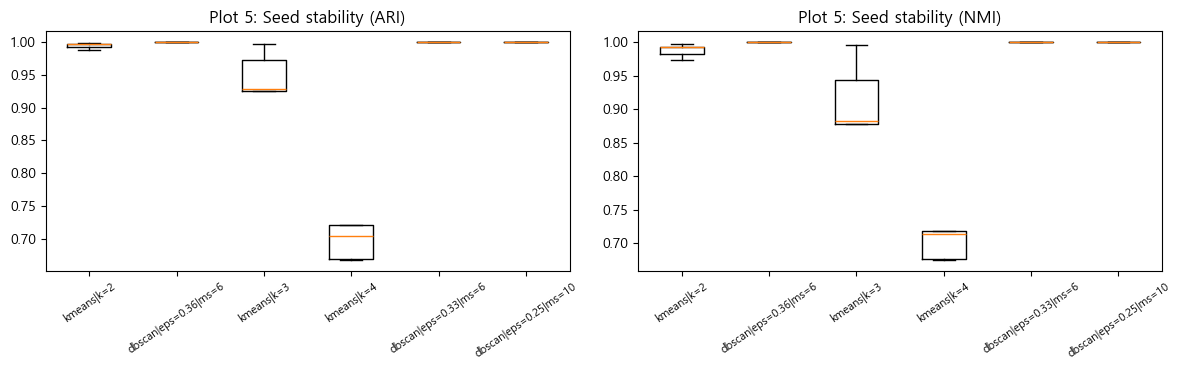

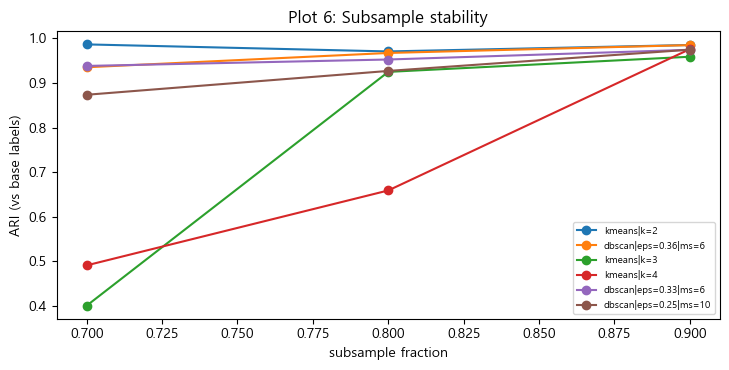

In [11]:
top_runs = valid_df.sort_values('score', ascending=False).head(6).copy()
display(top_runs[['run_id', 'backbone', 'method', 'n_clusters', 'noise_ratio', 'score']])

st_rows: List[Dict[str, Any]] = []
sub_rows: List[Dict[str, Any]] = []

for _, rr in top_runs.iterrows():
    rid = rr['run_id']
    bb = rr['backbone']
    method = rr['method']
    params = rr['params']
    X = backbone_data[bb]['X']
    base = labels_store[rid]

    for sd in SEEDS_STABILITY:
        if method == 'kmeans':
            model = KMeans(n_clusters=int(params['k']), random_state=int(sd), n_init='auto')
            lb = model.fit_predict(X).astype(np.int64)
        elif method == 'dbscan':
            model = DBSCAN(eps=float(params['eps']), min_samples=int(params['min_samples']), metric=params.get('metric', 'cosine'))
            lb = model.fit_predict(X).astype(np.int64)
        else:
            if not HAS_HDBSCAN:
                continue
            model = hdbscan.HDBSCAN(
                min_cluster_size=int(params['min_cluster_size']),
                min_samples=(None if params['min_samples'] is None else int(params['min_samples'])),
                metric=params.get('metric', 'euclidean'),
            )
            lb = model.fit_predict(X).astype(np.int64)
        st_rows.append({'run_id': rid, 'seed': int(sd), 'ARI': float(adjusted_rand_score(base, lb)), 'NMI': float(normalized_mutual_info_score(base, lb))})

    for frac in SUBSAMPLE_FRACS:
        rs = np.random.RandomState(RANDOM_STATE + int(frac * 1000))
        idx = rs.choice(np.arange(X.shape[0]), size=max(10, int(X.shape[0] * frac)), replace=False)
        Xs = X[idx]
        bs = base[idx]

        if method == 'kmeans':
            model = KMeans(n_clusters=int(params['k']), random_state=RANDOM_STATE, n_init='auto')
            lb = model.fit_predict(Xs).astype(np.int64)
        elif method == 'dbscan':
            model = DBSCAN(eps=float(params['eps']), min_samples=int(params['min_samples']), metric=params.get('metric', 'cosine'))
            lb = model.fit_predict(Xs).astype(np.int64)
        else:
            if not HAS_HDBSCAN:
                continue
            model = hdbscan.HDBSCAN(
                min_cluster_size=int(params['min_cluster_size']),
                min_samples=(None if params['min_samples'] is None else int(params['min_samples'])),
                metric=params.get('metric', 'euclidean'),
            )
            lb = model.fit_predict(Xs).astype(np.int64)

        sub_rows.append({'run_id': rid, 'frac': float(frac), 'ARI': float(adjusted_rand_score(bs, lb))})

st_df = pd.DataFrame(st_rows)
sub_df = pd.DataFrame(sub_rows)

# Plot 5
if not st_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
    run_order = top_runs['run_id'].tolist()
    data_ari = [st_df.loc[st_df['run_id'] == rid, 'ARI'].values for rid in run_order]
    data_nmi = [st_df.loc[st_df['run_id'] == rid, 'NMI'].values for rid in run_order]
    axes[0].boxplot(data_ari, tick_labels=[r.split('|', 1)[1] for r in run_order], showfliers=False)
    axes[0].set_title('Plot 5: Seed stability (ARI)')
    axes[0].tick_params(axis='x', labelrotation=35, labelsize=8)
    axes[1].boxplot(data_nmi, tick_labels=[r.split('|', 1)[1] for r in run_order], showfliers=False)
    axes[1].set_title('Plot 5: Seed stability (NMI)')
    axes[1].tick_params(axis='x', labelrotation=35, labelsize=8)
    fig.tight_layout()
    plt.show()

# Plot 6
if not sub_df.empty:
    fig, ax = plt.subplots(figsize=(7.4, 3.8))
    for rid in top_runs['run_id']:
        g = sub_df[sub_df['run_id'] == rid].sort_values('frac')
        if g.empty:
            continue
        ax.plot(g['frac'].values, g['ARI'].values, marker='o', label=rid.split('|', 1)[1])
    ax.set_xlabel('subsample fraction')
    ax.set_ylabel('ARI (vs base labels)')
    ax.set_title('Plot 6: Subsample stability')
    ax.legend(fontsize=7, loc='best')
    fig.tight_layout()
    plt.show()

## 6) UMAP vs t-SNE 시각화 비교

### Plot 3
- Top run UMAP small multiples

### Plot 4
- 최종 후보 UMAP vs t-SNE pair

c:\Users\user\anaconda3\envs\ytvenv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


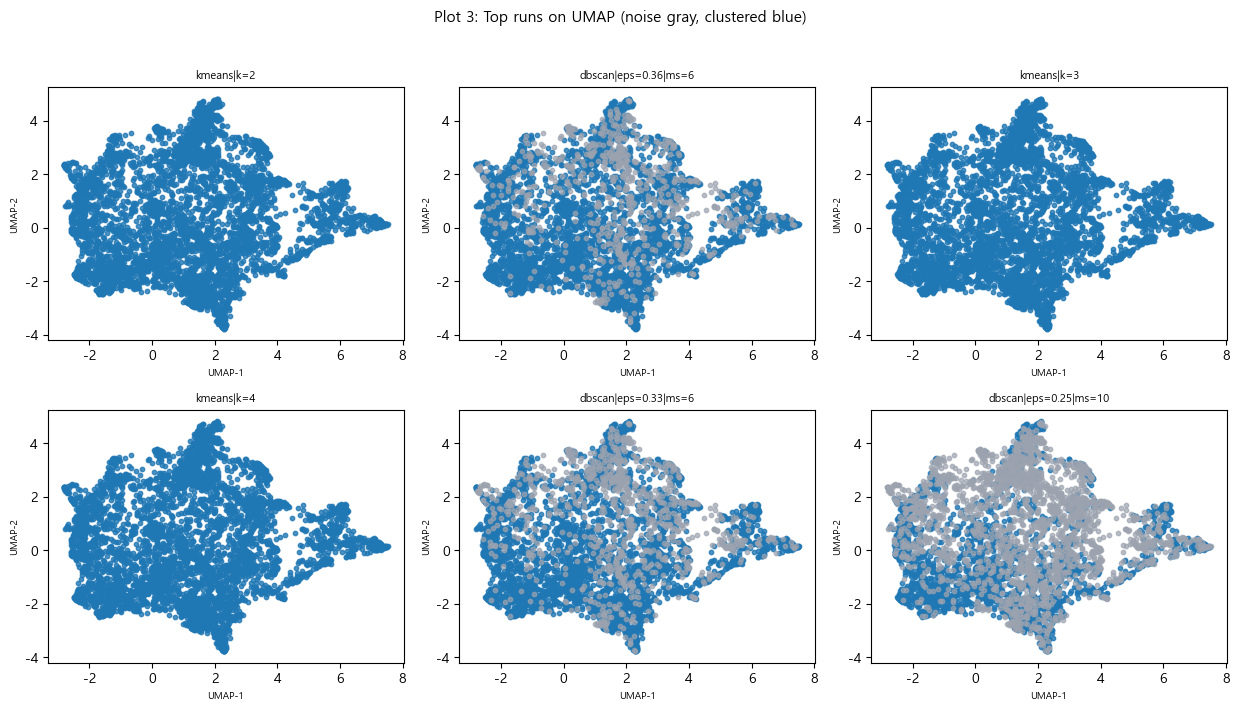

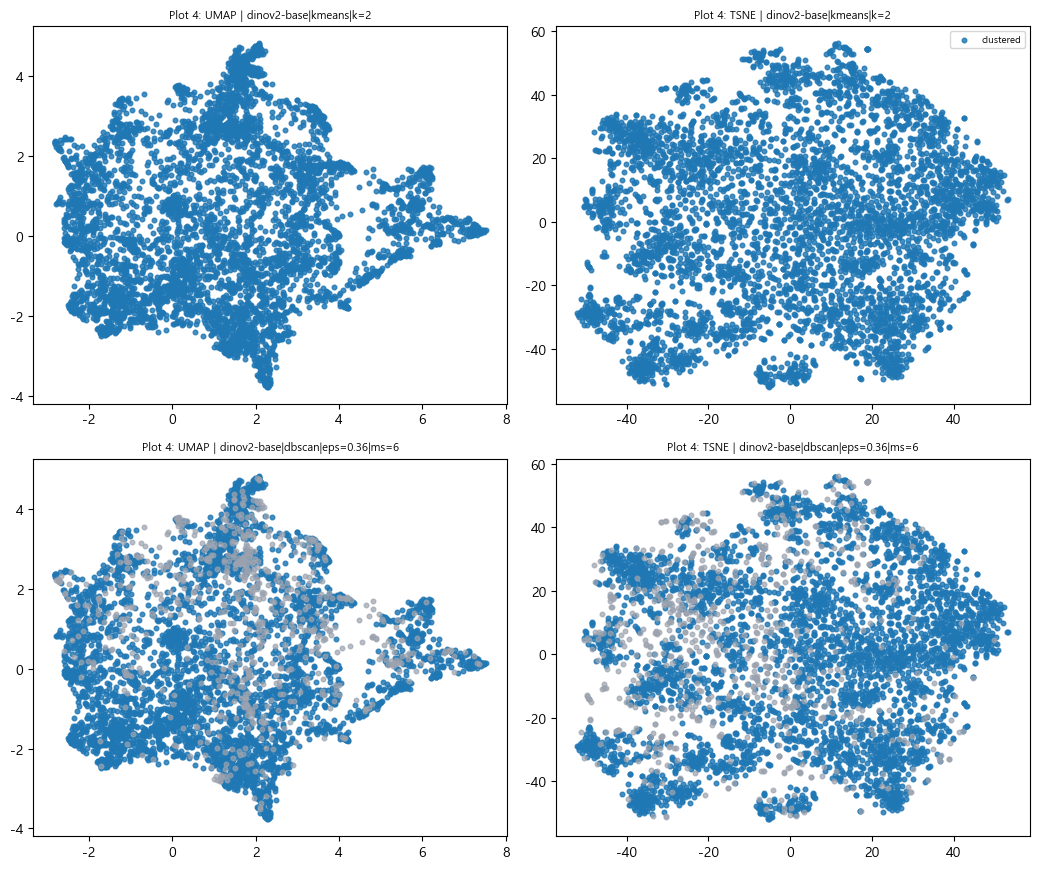

In [12]:
xy_map: Dict[str, Dict[str, np.ndarray]] = {}
for bb, d in backbone_data.items():
    X = d['X']
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=min(UMAP_NEIGHBORS, max(2, X.shape[0] - 1)),
        min_dist=UMAP_MIN_DIST,
        metric='cosine',
        random_state=RANDOM_STATE,
    )
    xy_umap = reducer.fit_transform(X)
    xy_tsne = TSNE(n_components=2, perplexity=min(TSNE_PERPLEXITY, max(5, (X.shape[0] - 1) // 3)), random_state=RANDOM_STATE, init='pca').fit_transform(X)
    xy_map[bb] = {'umap': xy_umap, 'tsne': xy_tsne}

# Plot 3: Top run small multiples on UMAP
plot_runs = top_runs.head(6)['run_id'].tolist()
fig, axes = plt.subplots(2, 3, figsize=(12.5, 7.2), squeeze=False)
for i, rid in enumerate(plot_runs):
    r, c = divmod(i, 3)
    ax = axes[r, c]
    bb = rid.split('|')[0]
    xy = xy_map[bb]['umap']
    lb = labels_store[rid]
    m_noise = lb == -1
    m_clustered = ~m_noise
    if np.any(m_clustered):
        ax.scatter(xy[m_clustered, 0], xy[m_clustered, 1], s=10, alpha=0.8, color='#1f77b4')
    if np.any(m_noise):
        ax.scatter(xy[m_noise, 0], xy[m_noise, 1], s=10, alpha=0.7, color='#9ca3af')
    ax.set_title(rid.split('|', 1)[1], fontsize=8)
    ax.set_xlabel('UMAP-1', fontsize=7)
    ax.set_ylabel('UMAP-2', fontsize=7)
for j in range(len(plot_runs), 6):
    r, c = divmod(j, 3)
    axes[r, c].axis('off')
fig.suptitle('Plot 3: Top runs on UMAP (noise gray, clustered blue)', fontsize=11)
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

# Plot 4: Best 2 runs UMAP vs t-SNE
final_candidates = valid_df.sort_values('score', ascending=False).head(2).copy()
if not final_candidates.empty:
    fig, axes = plt.subplots(len(final_candidates), 2, figsize=(10.5, 4.4 * len(final_candidates)), squeeze=False)
    for i, (_, rr) in enumerate(final_candidates.iterrows()):
        rid = rr['run_id']
        bb = rr['backbone']
        lb = labels_store[rid]
        for j, proj in enumerate(['umap', 'tsne']):
            ax = axes[i, j]
            xy = xy_map[bb][proj]
            m_noise = lb == -1
            m_clustered = ~m_noise
            if np.any(m_clustered):
                ax.scatter(xy[m_clustered, 0], xy[m_clustered, 1], s=11, alpha=0.82, color='#1f77b4', label='clustered')
            if np.any(m_noise):
                ax.scatter(xy[m_noise, 0], xy[m_noise, 1], s=11, alpha=0.7, color='#9ca3af', label='noise -1')
            ax.set_title(f'Plot 4: {proj.upper()} | {rid}', fontsize=8)
            if i == 0 and j == 1:
                ax.legend(fontsize=7, loc='best')
    fig.tight_layout()
    plt.show()

## 7) 피처 해석 (오버레이 + 분포)

### Plot 7
- 연속형 피처 오버레이 그리드

### Plot 8
- Top-1 age argmax 범주색

### Plot 9
- 클러스터별 피처 분포 박스플롯

### DBSCAN 노이즈·다중 설정·오버레이 (해석 가이드)
- DBSCAN **회색(-1)** 은 잘못된 표본이 아니라, **해당 `eps` / `min_samples`(및 거리·임베딩)에서 어떤 클러스터에도 속하지 않은 채널**입니다. **전체 채널**에 대한 결론을 쓸 때는 노이즈 비율과 함께 적고, **밀집 코어만** 비교한다는 전제가 있을 때만 라벨이 -1이 아닌 점만 씁니다.
- **서로 다른 군집 설정**은 서로 다른 파티션입니다. 피처 오버레이·Spearman 표는 **그 run의 라벨** 기준으로만 읽습니다.
- **Plot 7c**: 스윕 **상위 N개 run**에 대해 같은 스타일의 전 피처 UMAP 겹침을 자동 생성합니다. 모든 조합을 끝까지 돌리기보다 짧은 리스트에서 해석하고, **다중검정**(우연한 유의성)을 의식하는 편이 좋습니다.

final candidate: dinov2-base|kmeans|k=2
n_clusters: 2 noise_ratio: 0.0


,feature,rho,p,n
15,person_ratio,0.592237,0.000000e+00,5106
4,color_entropy,0.237174,3.195184e-66,5106
18,age_~17,-0.187587,1.172862e-41,5106
17,male_pct,0.184927,1.633512e-40,5106
16,female_pct,-0.184346,2.888306e-40,5106
11,blue_ratio,0.181682,3.846437e-39,5106
12,purple_ratio,0.175839,9.792999e-37,5106
13,pink_ratio,0.169748,2.573330e-34,5106
6,red_ratio,0.167498,1.914454e-33,5106
22,age_45~54,0.154749,9.790603e-29,5106


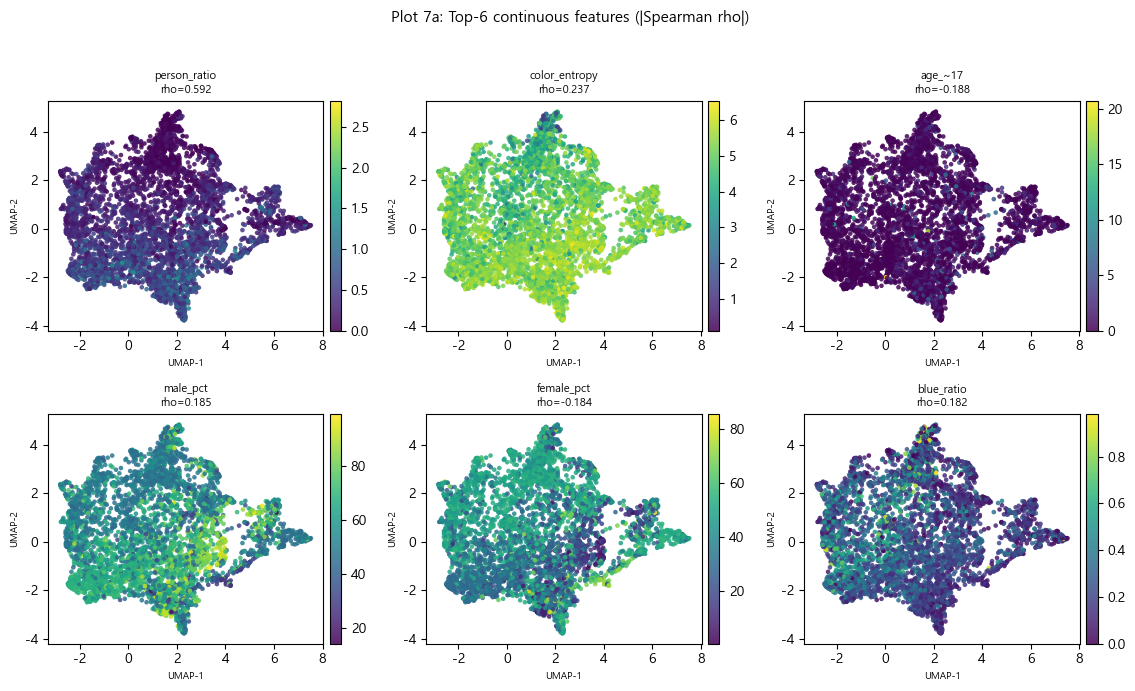

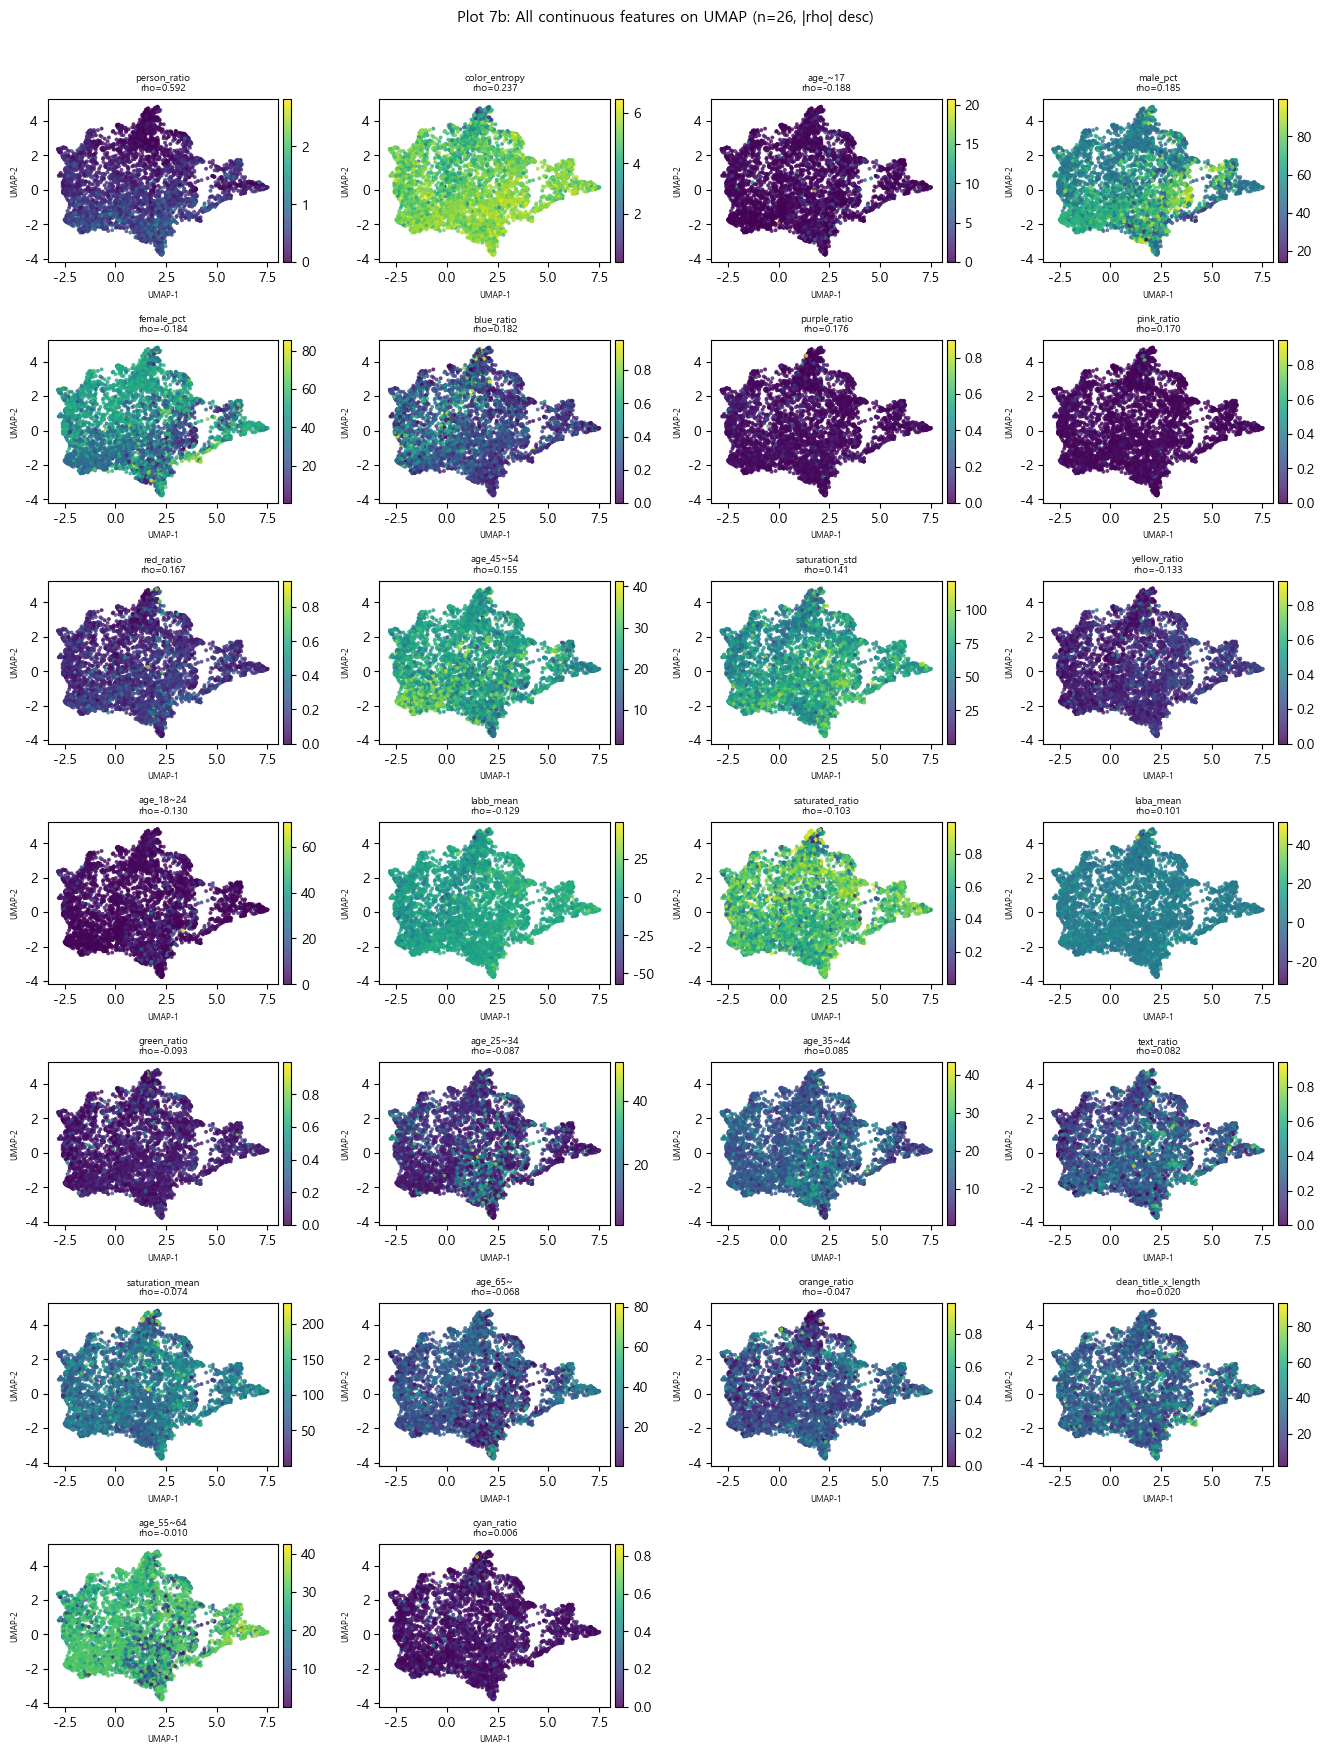

saved: C:\Users\user\Desktop\26-1_URP\artifacts\SOCIETY\analysis\plots\multi_run_feature_overlays\dinov2-base_kmeans_k=2_all_features_umap.png


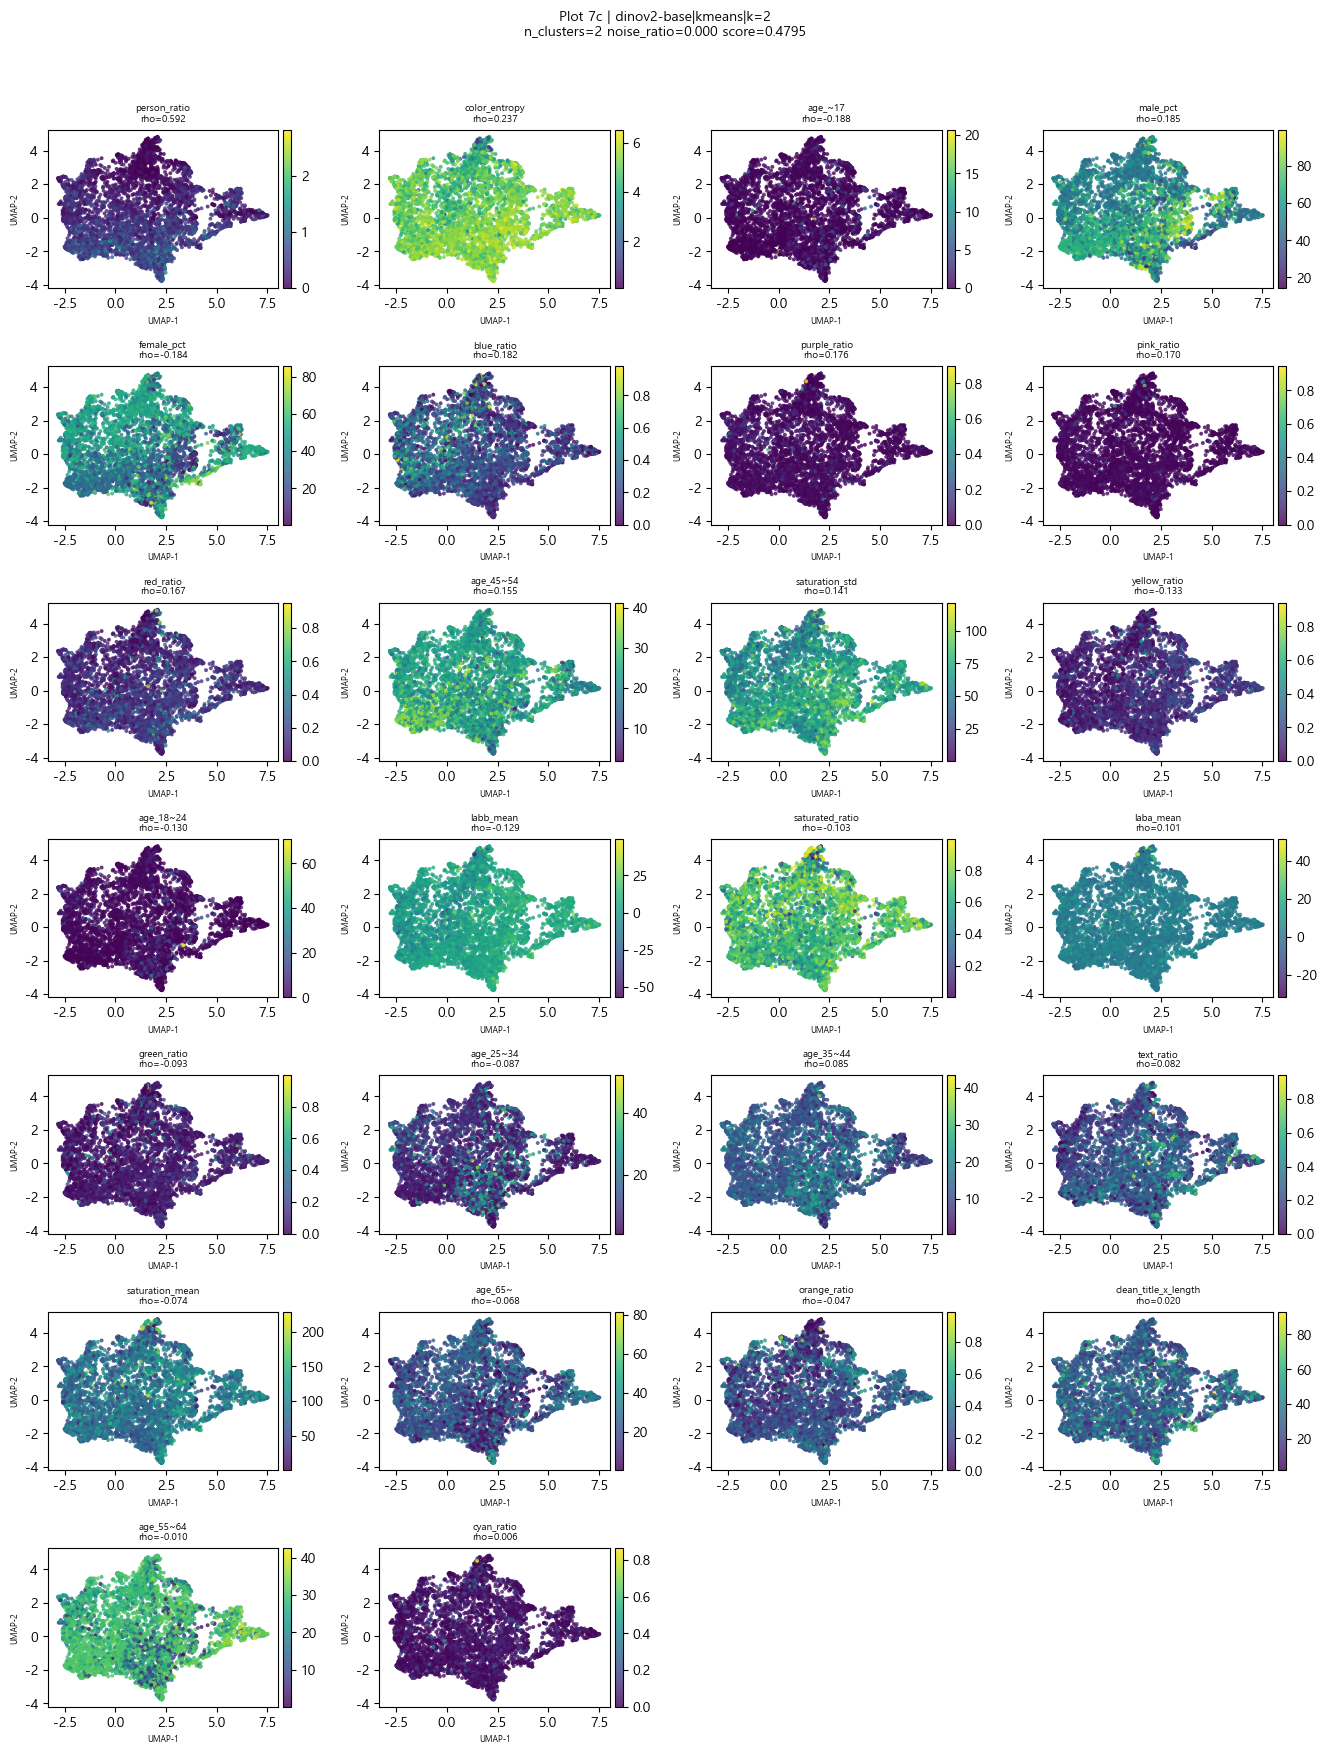

saved: C:\Users\user\Desktop\26-1_URP\artifacts\SOCIETY\analysis\plots\multi_run_feature_overlays\dinov2-base_dbscan_eps=0.36_ms=6_all_features_umap.png


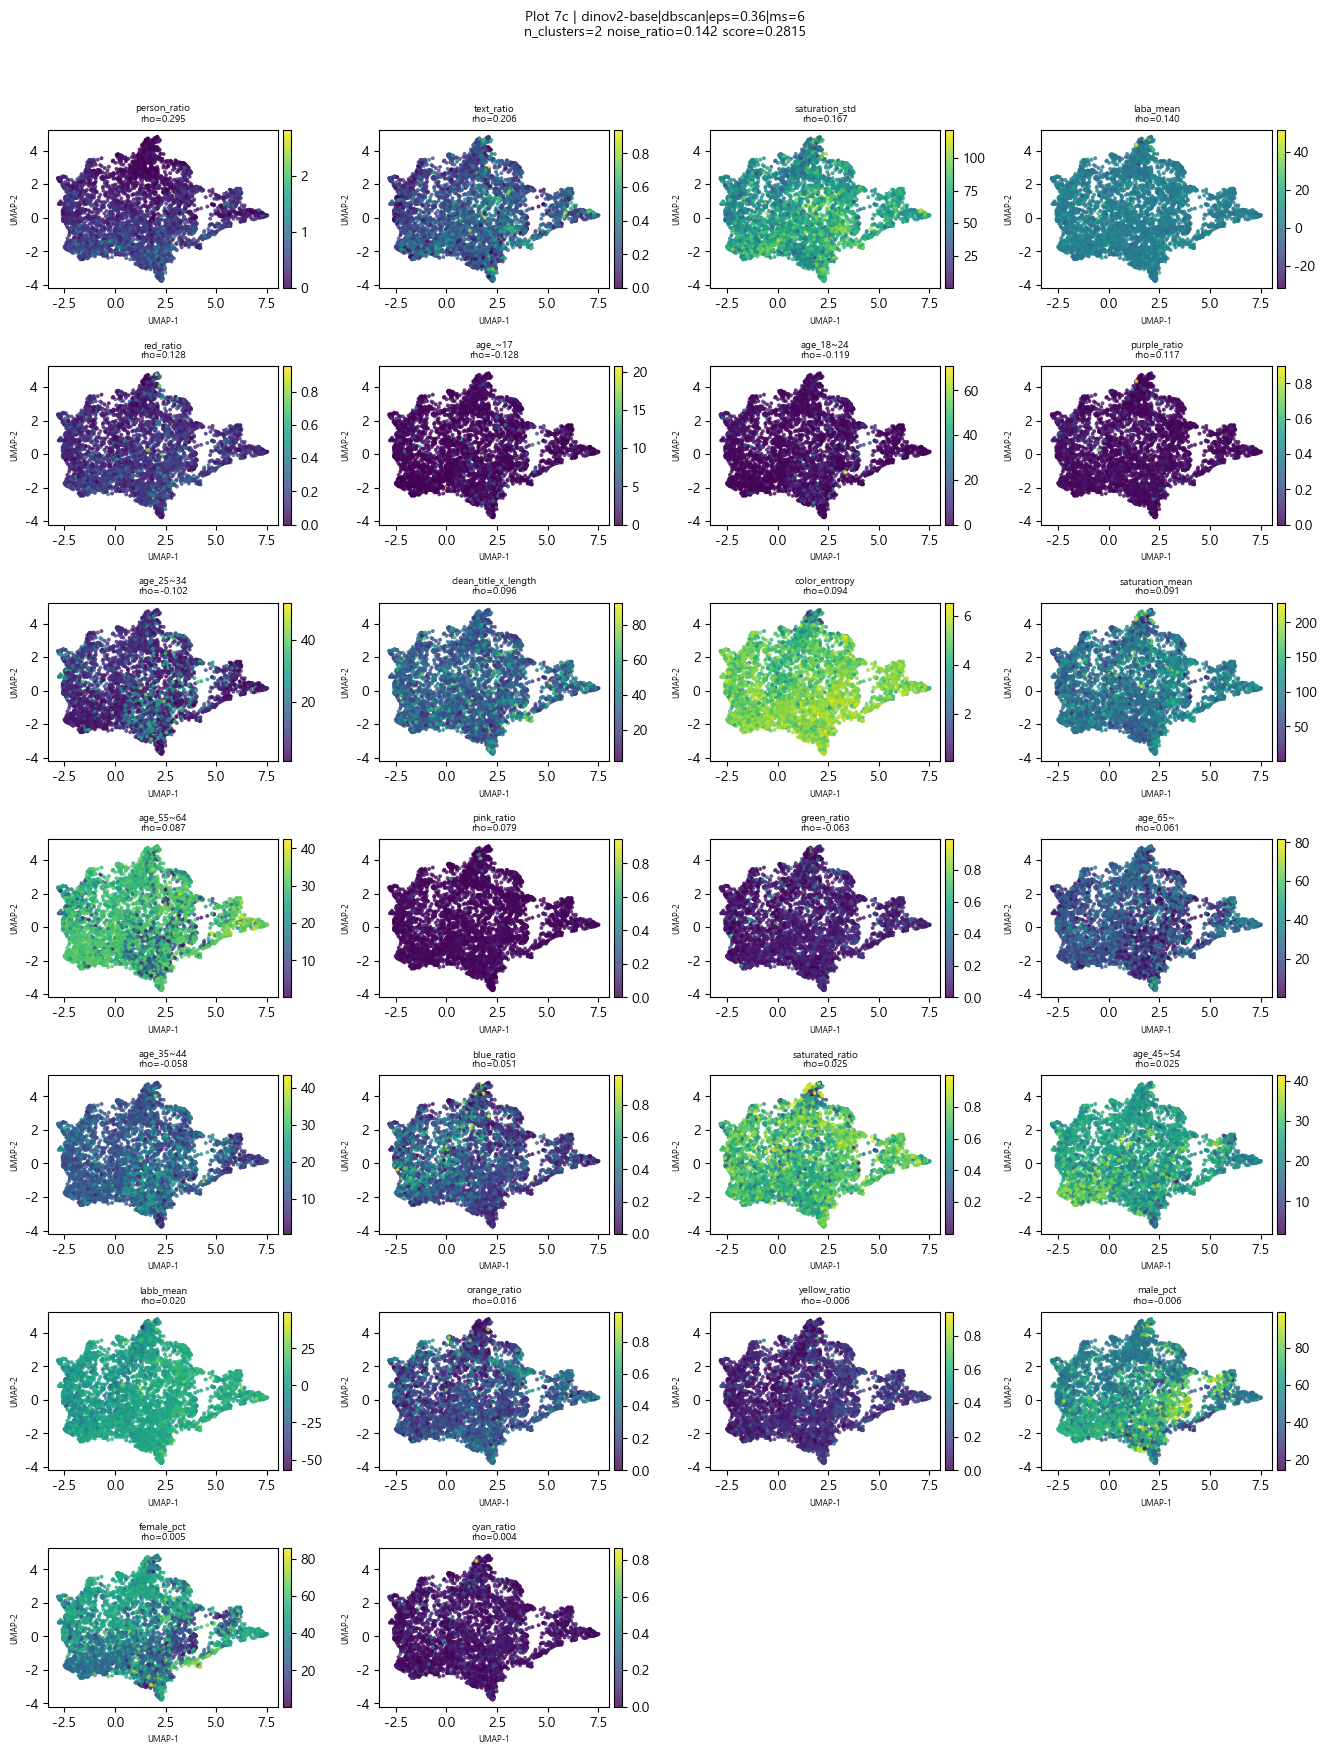

saved: C:\Users\user\Desktop\26-1_URP\artifacts\SOCIETY\analysis\plots\multi_run_feature_overlays\dinov2-base_kmeans_k=3_all_features_umap.png


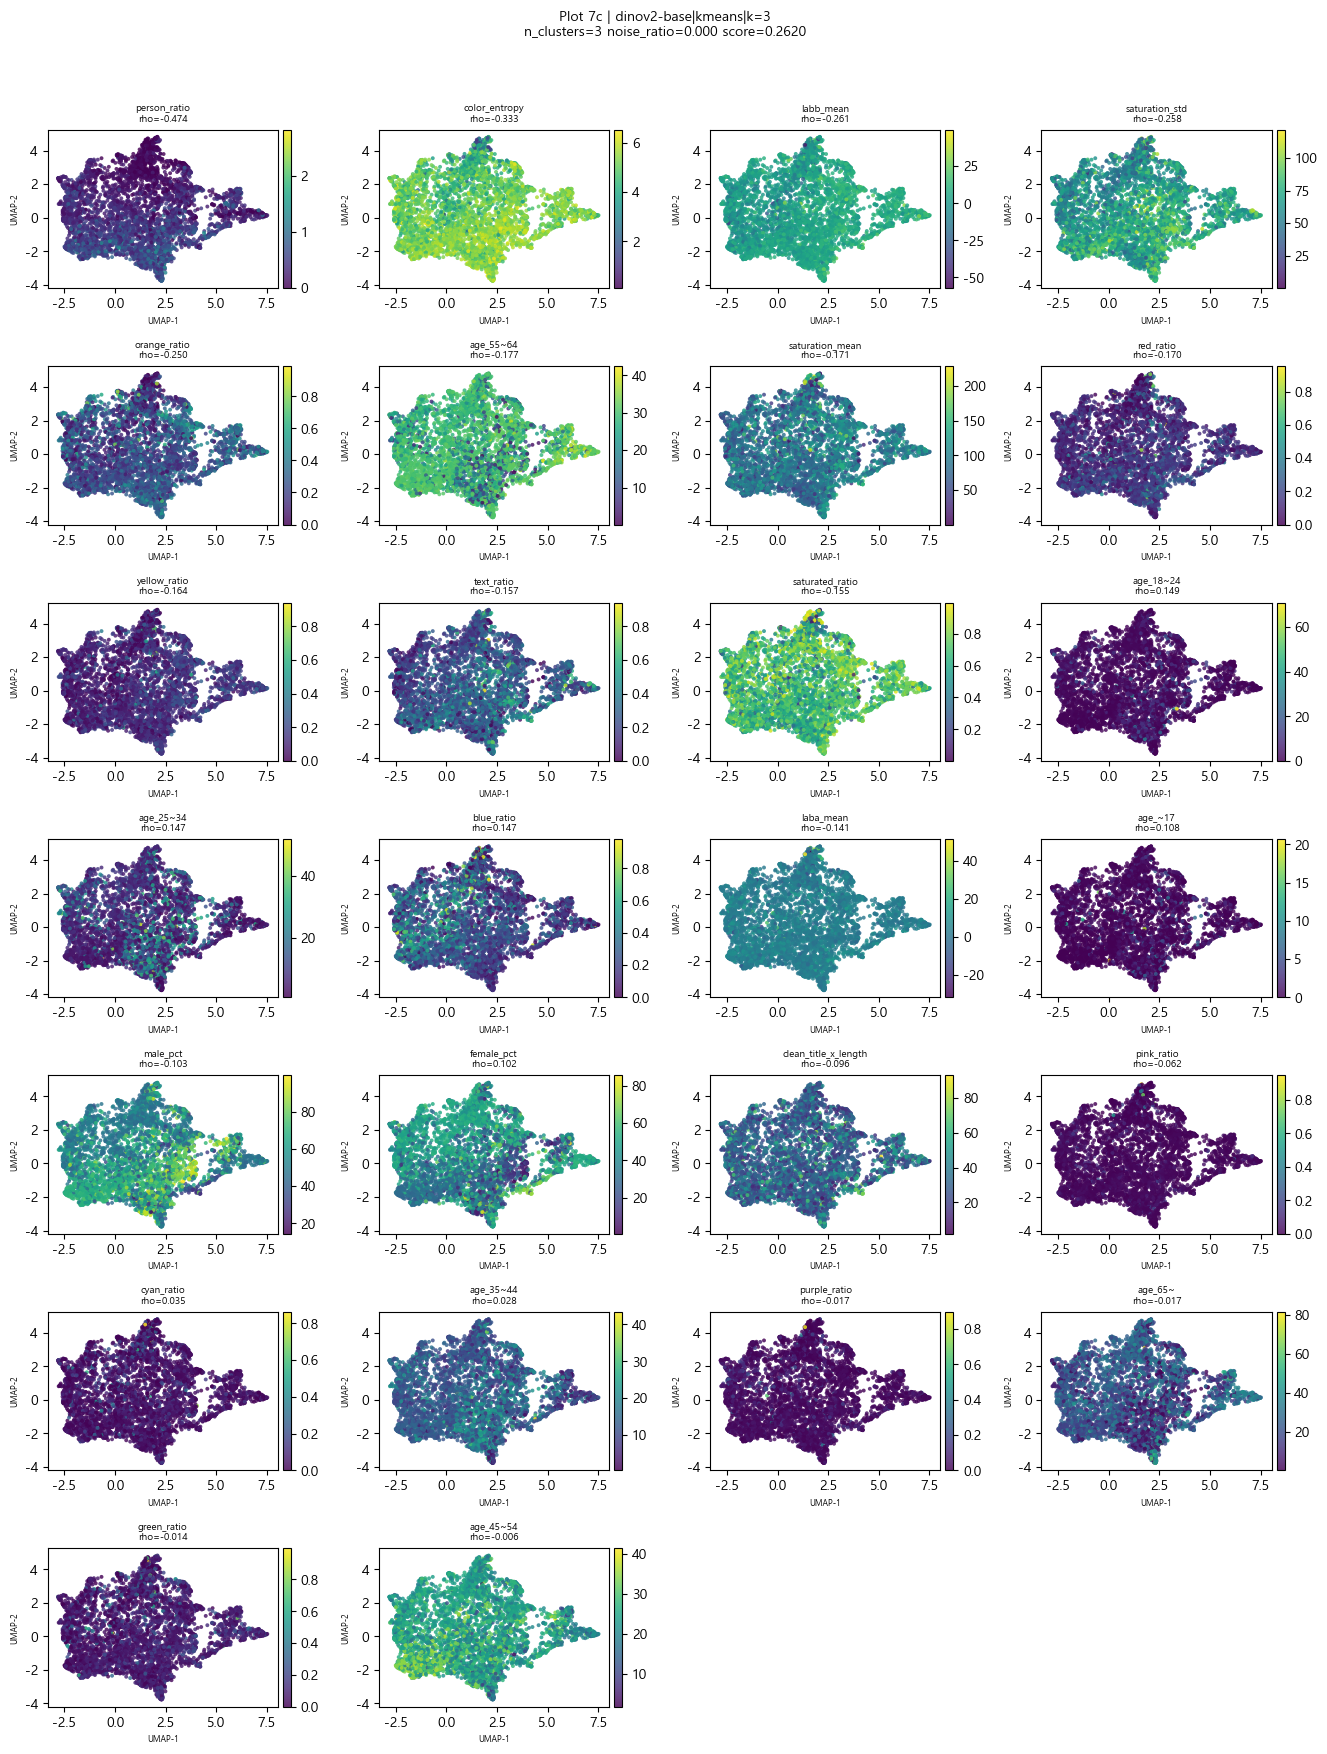

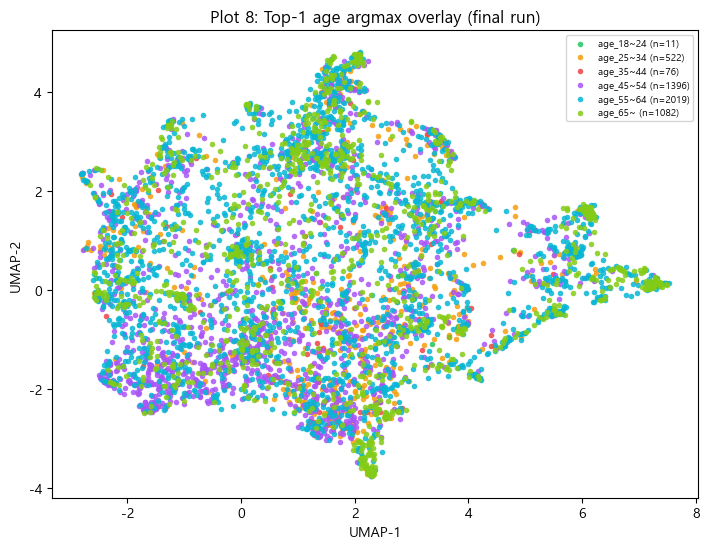

C:\Users\user\AppData\Local\Temp\ipykernel_18744\3420920844.py:189: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[str(k) for k in cls], showfliers=False)
C:\Users\user\AppData\Local\Temp\ipykernel_18744\3420920844.py:189: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[str(k) for k in cls], showfliers=False)
C:\Users\user\AppData\Local\Temp\ipykernel_18744\3420920844.py:189: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[str(k) for k in cls], showfliers=False)
C:\Users\user\AppData\Local\Temp\ipykernel_18744\3420920844.py:189: MatplotlibDeprecatio

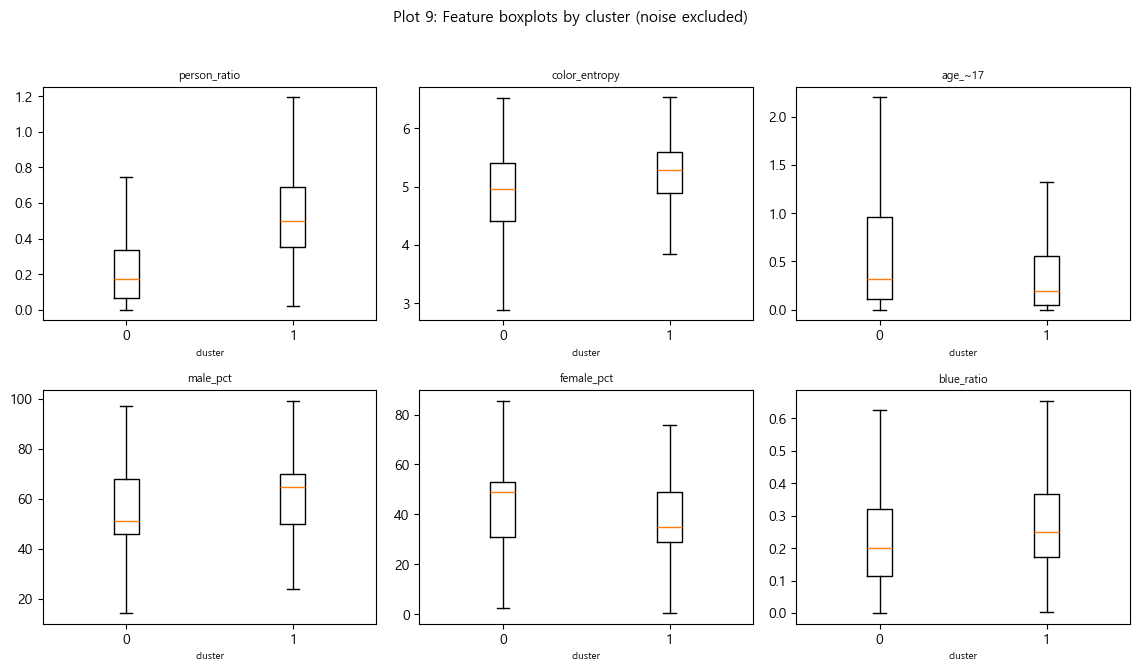

In [13]:
# 최종 후보: valid_df score 1위 자동 선택
final_run = valid_df.sort_values('score', ascending=False).iloc[0]
final_run_id = str(final_run['run_id'])
final_backbone = str(final_run['backbone'])
final_labels = labels_store[final_run_id]
final_xy = xy_map[final_backbone]['umap']
final_merged = backbone_data[final_backbone]['merged']
final_F = backbone_data[final_backbone]['F']
final_feature_cols = backbone_data[final_backbone]['feature_cols']

print('final candidate:', final_run_id)
print('n_clusters:', int(len(set(final_labels.tolist()) - {-1})), 'noise_ratio:', float((final_labels == -1).sum()/len(final_labels)))

# Plot 7: Spearman vs cluster label + UMAP overlays (요약 6개 + 전체 피처)
from scipy.stats import spearmanr

summ = []
for j, col in enumerate(final_feature_cols):
    v = final_F[:, j]
    m = np.isfinite(v)
    if m.sum() < 5:
        continue
    rho, p = spearmanr(final_labels[m], v[m])
    summ.append({'feature': col, 'rho': float(rho), 'p': float(p), 'n': int(m.sum())})

summ_df = pd.DataFrame(summ).sort_values('rho', key=np.abs, ascending=False)
display(summ_df)

# Plot 9 등에서 쓰는 상위 6개 (기존과 동일)
plot_feats = summ_df.head(6)['feature'].tolist()

# Plot 7a — 요약: |rho| 상위 6개만 큰 패널
fig, axes = plt.subplots(2, 3, figsize=(11.5, 7.0), squeeze=False)
for i, feat in enumerate(plot_feats):
    r, c = divmod(i, 3)
    ax = axes[r, c]
    j = final_feature_cols.index(feat)
    v = final_F[:, j]
    m = np.isfinite(v)
    sc = ax.scatter(final_xy[m, 0], final_xy[m, 1], c=v[m], cmap='viridis', s=11, alpha=0.85, linewidths=0)
    rho = float(summ_df.loc[summ_df['feature'] == feat, 'rho'].iloc[0])
    ax.set_title(f'{feat}\nrho={rho:.3f}', fontsize=8)
    ax.set_xlabel('UMAP-1', fontsize=7)
    ax.set_ylabel('UMAP-2', fontsize=7)
    fig.colorbar(sc, ax=ax, fraction=0.08, pad=0.02)
fig.suptitle('Plot 7a: Top-6 continuous features (|Spearman rho|)', fontsize=11)
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

# Plot 7b — 전체 피처(|rho| 큰 순). 패널이 많으면 세로로 길어짐
all_feats = summ_df['feature'].tolist()
if all_feats:
    ncols = 4
    nrows = int(np.ceil(len(all_feats) / ncols))
    fig, axes_arr = plt.subplots(nrows, ncols, figsize=(3.35 * ncols, 2.55 * nrows), squeeze=False)
    axes = np.atleast_2d(axes_arr)
    for idx, feat in enumerate(all_feats):
        r, c = divmod(idx, ncols)
        ax = axes[r, c]
        j = final_feature_cols.index(feat)
        v = final_F[:, j]
        m = np.isfinite(v)
        sc = ax.scatter(final_xy[m, 0], final_xy[m, 1], c=v[m], cmap='viridis', s=8, alpha=0.82, linewidths=0)
        rho = float(summ_df.loc[summ_df['feature'] == feat, 'rho'].iloc[0])
        ax.set_title(f'{feat}\nrho={rho:.3f}', fontsize=7)
        ax.set_xlabel('UMAP-1', fontsize=6)
        ax.set_ylabel('UMAP-2', fontsize=6)
        fig.colorbar(sc, ax=ax, fraction=0.08, pad=0.02)
    for k in range(len(all_feats), nrows * ncols):
        r, c = divmod(k, ncols)
        axes[r, c].axis('off')
    fig.suptitle(
        f'Plot 7b: All continuous features on UMAP (n={len(all_feats)}, |rho| desc)',
        fontsize=11,
    )
    fig.tight_layout(rect=(0, 0, 1, 0.97))
    plt.show()

# Plot 7c — score 상위 N개 run: run마다 라벨이 다르므로 Spearman·그리드를 각각 계산 (파티션별 비교)
SAVE_MULTI_RUN_OVERLAYS = True  # False면 화면에만 표시
OVERLAY_SHORTLIST_N = min(3, len(top_runs))


def _feature_spearman_vs_labels(labels: np.ndarray, F: np.ndarray, feature_cols: list[str]) -> pd.DataFrame:
    rows: list[dict] = []
    for j, col in enumerate(feature_cols):
        v = F[:, j]
        m = np.isfinite(v)
        if int(m.sum()) < 5:
            continue
        rho, p = spearmanr(labels[m], v[m])
        rows.append({'feature': col, 'rho': float(rho), 'p': float(p), 'n': int(m.sum())})
    return pd.DataFrame(rows).sort_values('rho', key=np.abs, ascending=False)


def _sanitize_run_id(rid: str) -> str:
    return rid.replace('|', '_').replace('/', '_').replace('\\', '_')


ov_dir = OUT_PLOTS / 'multi_run_feature_overlays'
if SAVE_MULTI_RUN_OVERLAYS:
    ov_dir.mkdir(parents=True, exist_ok=True)

for _, rr in top_runs.head(OVERLAY_SHORTLIST_N).iterrows():
    rid = str(rr['run_id'])
    bb = str(rr['backbone'])
    lab = labels_store[rid]
    xy_run = xy_map[bb]['umap']
    Fur = backbone_data[bb]['F']
    cols = backbone_data[bb]['feature_cols']
    if lab.shape[0] != xy_run.shape[0] or lab.shape[0] != Fur.shape[0]:
        print(f'[skip Plot 7c] shape mismatch {rid}: lab={lab.shape} xy={xy_run.shape} F={Fur.shape}')
        continue
    sdf = _feature_spearman_vs_labels(lab, Fur, cols)
    feats_run = sdf['feature'].tolist()
    if not feats_run:
        continue
    ncls = int(len(set(lab.tolist()) - {-1}))
    nr = float((lab == -1).sum() / len(lab))
    ttl = (
        f'Plot 7c | {rid}\n'
        f'n_clusters={ncls} noise_ratio={nr:.3f} score={float(rr["score"]):.4f}'
    )
    ncols_ov = 4
    nrows_ov = int(np.ceil(len(feats_run) / ncols_ov))
    fig, axes_arr = plt.subplots(
        nrows_ov, ncols_ov, figsize=(3.35 * ncols_ov, 2.55 * nrows_ov), squeeze=False
    )
    axes_ov = np.atleast_2d(axes_arr)
    for idx, feat in enumerate(feats_run):
        rr_, cc_ = divmod(idx, ncols_ov)
        ax = axes_ov[rr_, cc_]
        j = cols.index(feat)
        v = Fur[:, j]
        m = np.isfinite(v)
        sc = ax.scatter(
            xy_run[m, 0], xy_run[m, 1], c=v[m], cmap='viridis', s=8, alpha=0.82, linewidths=0
        )
        rho = float(sdf.loc[sdf['feature'] == feat, 'rho'].iloc[0])
        ax.set_title(f'{feat}\nrho={rho:.3f}', fontsize=7)
        ax.set_xlabel('UMAP-1', fontsize=6)
        ax.set_ylabel('UMAP-2', fontsize=6)
        fig.colorbar(sc, ax=ax, fraction=0.08, pad=0.02)
    for k in range(len(feats_run), nrows_ov * ncols_ov):
        rr_, cc_ = divmod(k, ncols_ov)
        axes_ov[rr_, cc_].axis('off')
    fig.suptitle(ttl, fontsize=10)
    fig.tight_layout(rect=(0, 0, 1, 0.96))
    if SAVE_MULTI_RUN_OVERLAYS:
        fp = ov_dir / f'{_sanitize_run_id(rid)}_all_features_umap.png'
        fig.savefig(fp, dpi=160, bbox_inches='tight')
        print('saved:', fp)
    plt.show()

# Plot 8: top-1 age argmax
age_cols = [c for c in final_feature_cols if c.startswith('age_')]
if age_cols:
    A = final_merged[age_cols].apply(pd.to_numeric, errors='coerce').to_numpy(dtype=np.float64)
    valid = np.isfinite(A).any(axis=1)
    fill = np.where(np.isfinite(A), A, -np.inf)
    top_idx = np.full(A.shape[0], -1, dtype=int)
    top_idx[valid] = np.argmax(fill[valid], axis=1)

    colors = ['#3b82f6','#22c55e','#f59e0b','#ef4444','#a855f7','#06b6d4','#84cc16'][:len(age_cols)]
    fig, ax = plt.subplots(figsize=(7.2, 5.6))
    for i, col in enumerate(age_cols):
        mm = valid & (top_idx == i)
        if not np.any(mm):
            continue
        ax.scatter(final_xy[mm, 0], final_xy[mm, 1], s=16, alpha=0.85, linewidths=0, color=colors[i], label=f'{col} (n={int(mm.sum())})')
    ax.set_title('Plot 8: Top-1 age argmax overlay (final run)')
    ax.set_xlabel('UMAP-1')
    ax.set_ylabel('UMAP-2')
    ax.legend(fontsize=7, loc='best')
    fig.tight_layout()
    plt.show()

# Plot 9: feature distributions by cluster (top 6)
fig, axes = plt.subplots(2, 3, figsize=(11.5, 6.8), squeeze=False)
for i, feat in enumerate(plot_feats):
    r, c = divmod(i, 3)
    ax = axes[r, c]
    y = pd.to_numeric(final_merged[feat], errors='coerce')
    dfp = pd.DataFrame({'cluster': final_labels, 'value': y})
    dfp = dfp[np.isfinite(dfp['value']) & (dfp['cluster'] != -1)]
    cls = sorted(dfp['cluster'].unique())
    data = [dfp.loc[dfp['cluster'] == k, 'value'].values for k in cls]
    if len(data) >= 2:
        ax.boxplot(data, tick_labels=[str(k) for k in cls], showfliers=False)
    ax.set_title(feat, fontsize=8)
    ax.set_xlabel('cluster', fontsize=7)
fig.suptitle('Plot 9: Feature boxplots by cluster (noise excluded)', fontsize=11)
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

## 8) Permutation importance-style + 최종 선정 근거

### Plot 10
- 피처 셔플 시 label 예측 성능(균형정확도) 감소량

### Plot 11
- 최종 선택 요약 카드(점수/안정성/해석성)

,feature,delta_bal_acc
15,person_ratio,0.241147
3,labb_mean,0.010949
17,male_pct,0.007072
0,saturation_mean,0.005472
1,saturation_std,0.004691
11,blue_ratio,0.003921
5,saturated_ratio,0.003899
8,yellow_ratio,0.002358
10,cyan_ratio,0.002351
16,female_pct,0.000814


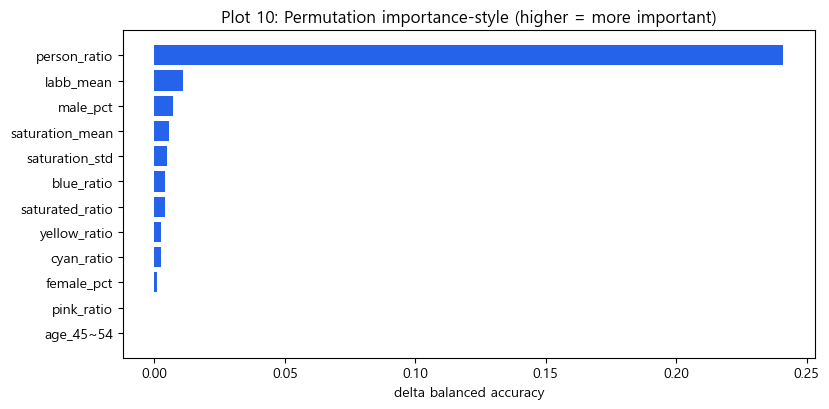

{
  "selected_run_id": "dinov2-base|kmeans|k=2",
  "backbone": "dinov2-base",
  "method": "kmeans",
  "n_clusters": 2,
  "noise_ratio": 0.0,
  "quality_score": 0.47952005854316837,
  "silhouette_pref": 0.08469309894938624,
  "top_interpret_features": [
    "person_ratio",
    "labb_mean",
    "male_pct",
    "saturation_mean",
    "saturation_std"
  ]
}


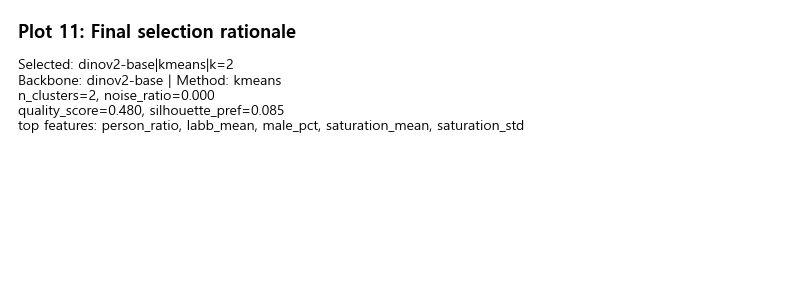

In [10]:
# Plot 10: permutation importance-style (feature -> cluster label predictability)
mask = final_labels != -1
Xf = pd.DataFrame(final_F[mask], columns=final_feature_cols).apply(pd.to_numeric, errors='coerce')
Xf = Xf.fillna(Xf.median(numeric_only=True))
yf = final_labels[mask]

if len(np.unique(yf)) >= 2 and Xf.shape[0] >= 80:
    Xtr, Xte, ytr, yte = train_test_split(Xf, yf, test_size=0.25, random_state=RANDOM_STATE, stratify=yf)
    clf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
    clf.fit(Xtr, ytr)
    base = balanced_accuracy_score(yte, clf.predict(Xte))

    drops = []
    rng = np.random.RandomState(RANDOM_STATE)
    for col in Xte.columns:
        Xt = Xte.copy()
        Xt[col] = rng.permutation(Xt[col].values)
        sc = balanced_accuracy_score(yte, clf.predict(Xt))
        drops.append({'feature': col, 'delta_bal_acc': float(base - sc)})

    perm_df = pd.DataFrame(drops).sort_values('delta_bal_acc', ascending=False)
    display(perm_df.head(12))

    fig, ax = plt.subplots(figsize=(8.4, 4.2))
    top = perm_df.head(12)
    ax.barh(top['feature'][::-1], top['delta_bal_acc'][::-1], color='#2563eb')
    ax.set_title('Plot 10: Permutation importance-style (higher = more important)')
    ax.set_xlabel('delta balanced accuracy')
    fig.tight_layout()
    plt.show()
else:
    perm_df = pd.DataFrame(columns=['feature', 'delta_bal_acc'])
    print('Permutation importance skipped: not enough clustered samples/classes.')

# Plot 11: final selection summary card
final_summary = {
    'selected_run_id': final_run_id,
    'backbone': final_backbone,
    'method': final_run['method'],
    'n_clusters': int(len(set(final_labels.tolist()) - {-1})),
    'noise_ratio': float((final_labels == -1).sum() / len(final_labels)),
    'quality_score': float(final_run['score']),
    'silhouette_pref': float(final_run['sil_pref']) if np.isfinite(final_run['sil_pref']) else np.nan,
    'top_interpret_features': perm_df.head(5)['feature'].tolist() if not perm_df.empty else [],
}
print(json.dumps(final_summary, ensure_ascii=False, indent=2))

fig, ax = plt.subplots(figsize=(8.2, 3.0))
ax.axis('off')
lines = [
    f"Selected: {final_summary['selected_run_id']}",
    f"Backbone: {final_summary['backbone']} | Method: {final_summary['method']}",
    f"n_clusters={final_summary['n_clusters']}, noise_ratio={final_summary['noise_ratio']:.3f}",
    f"quality_score={final_summary['quality_score']:.3f}, silhouette_pref={final_summary['silhouette_pref']:.3f}",
    f"top features: {', '.join(final_summary['top_interpret_features'][:5])}",
]
ax.text(0.01, 0.95, 'Plot 11: Final selection rationale', fontsize=13, va='top', fontweight='bold')
ax.text(0.01, 0.82, '\n'.join(lines), fontsize=10, va='top')
fig.tight_layout()
plt.show()